# 第二阶段：多维度探索性数据分析

本 Notebook 用于完成酒店预订行为与取消预测项目的 EDA。分析目标是从整体业务、取消行为、客户群体、价格、渠道和季节性等维度，挖掘预订行为规律和取消风险因素，为后续特征工程和建模提供依据。

## 1. 导入工具库与路径配置

In [1]:
# 配置 EDA 所需路径、绘图风格和中文字体。
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from config import FEATURE_PARQUET_PATH

FIGURE_DIR = PROJECT_ROOT / "reports" / "eda_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


## 2. 读取特征工程数据

In [2]:
# 读取特征工程后的数据，EDA 使用原始尺度字段以便解释业务含义。
if not FEATURE_PARQUET_PATH.exists():
    raise FileNotFoundError(f"特征工程数据不存在，请先运行 feature_engineering.ipynb：{FEATURE_PARQUET_PATH}")

df = pd.read_parquet(FEATURE_PARQUET_PATH)
df["arrival_date"] = pd.to_datetime(df["arrival_date"])
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

required_feature_columns = [
    "hotel_type",
    "arrival_month",
    "arrival_month_num",
    "arrival_day_of_week",
    "is_weekend",
    "season_type",
    "holiday_proxy",
    "lead_time_group",
    "special_request_group",
    "estimated_revenue",
    "rfm_segment",
]
missing_feature_columns = [col for col in required_feature_columns if col not in df.columns]
if missing_feature_columns:
    raise ValueError(f"特征工程数据缺少字段：{missing_feature_columns}")

print(f"特征数据行数：{df.shape[0]:,}")
print(f"特征数据列数：{df.shape[1]:,}")
df.head()

特征数据行数：110,628
特征数据列数：86


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city,total_stays,arrival_date,hotel_type,arrival_month_num,arrival_month,arrival_quarter,arrival_quarter_label,arrival_day_of_week,is_weekend,is_holiday_proxy,holiday_proxy,is_near_holiday_proxy,season_type,is_peak_season,is_low_season,total_guests,has_children_or_babies,room_type_matched,has_booking_changes,has_special_requests,has_car_parking_request,lead_time_group,special_request_group,customer_group_key,estimated_revenue,group_recency_days,group_booking_count,group_avg_revenue,rfm_value_score,rfm_segment,is_high_value_customer_group,customer_group_hist_booking_count,customer_group_hist_cancel_rate,country_hist_booking_count,country_hist_cancel_rate,agent_hist_booking_count,agent_hist_cancel_rate,hotel_hist_booking_count,hotel_hist_cancel_rate,is_high_risk_country,is_high_risk_agent,hotel_hist_avg_adr,city_hist_avg_adr,customer_group_hist_avg_adr,price_to_hotel_hist_avg,price_to_city_hist_avg,price_to_customer_group_hist_avg,price_volatility_index,price_sensitivity_score,hotel_daily_booking_count,estimated_occupancy_proxy,demand_pressure_score,cancellation_risk_score
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh,0,2024-07-27,Resort Hotel,7,2024-07,3,2024Q3,5,1,1,周末/节假日代理,0,旺季,1,0,2.0,0,1,1,0,0,181+,0,Transient|Direct|Direct|0,0.0,1,9199,314.418213,15,高价值,1,5280,0.145076,26249,0.567107,8942,0.247372,1354,0.242245,1,0,82.035667,96.760925,107.124695,0.000000,0.000000,0.000000,0.628396,1,6,0.352941,1,0.468359
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai,0,2024-04-28,Resort Hotel,4,2024-04,2,2024Q2,6,1,1,周末/节假日代理,0,平季,0,0,2.0,0,1,1,0,0,181+,0,Transient|Direct|Direct|0,0.0,1,9199,314.418213,15,高价值,1,3007,0.143665,14885,0.565267,5052,0.251188,754,0.263926,0,0,83.775848,96.044243,106.139435,0.000000,0.000000,0.000000,0.565583,1,6,0.375000,1,0.473831
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi,1,2024-09-10,Resort Hotel,9,2024-09,3,2024Q3,1,0,0,工作日,0,平季,0,0,1.0,0,0,0,0,0,0-7,0,Transient|Direct|Direct|0,75.0,1,9199,314.418213,15,高价值,1,6356,0.147892,7365,0.210319,10815,0.249376,1571,0.250159,0,0,81.355942,96.428558,107.140785,0.921875,0.777778,0.700014,0.561910,1,8,0.444444,2,0.278788
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata,1,2024-08-14,Resort Hotel,8,2024-08,3,2024Q3,2,0,0,工作日,0,平季,0,0,1.0,0,1,0,0,0,8-30,0,Transient|Corporate|Corporate|0,75.0,1,2036,123.485298,13,高价值,1,1273,0.227808,6635,0.211756,0,0.000000,1392,0.274425,0,0,85.713806,97.885902,67.879440,0.875005,0.766198,1.104900,0.560142,4,12,0.857143,3,0.273685
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow,2,2024-09-14,Resort Hotel,9,2024-09,3,2024Q3,5,1,1,周末/节假日代理,0,平季,0,0,2.0,0,1,0,1,0,8-30,1,Transient|Online TA|TA/TO|0,196.0,1,45891,368.200653,15,高价值,1,32492,0.379416,7493,0.210863,8065,0.364414,1521,0.249836,0,0,83.541191,96.566704,112.119072,1.173074,1.014843,0.874071,0.566750,2,

## 3. 绘图工具函数

In [3]:
# 定义图表保存和分组统计函数，避免每张图重复写保存逻辑。
def save_current_fig(filename):
    """保存当前图表到 reports/eda_figures。"""
    output_path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    return output_path.relative_to(PROJECT_ROOT)


def rate_table(data, group_col):
    """按单个字段计算预订量、取消量、取消率、平均房价。"""
    return (
        data.groupby(group_col, dropna=False)
        .agg(
            booking_count=("is_canceled", "size"),
            cancellation_count=("is_canceled", "sum"),
            cancellation_rate=("is_canceled", "mean"),
            avg_adr=("adr", "mean"),
        )
        .reset_index()
        .sort_values("booking_count", ascending=False)
    )


## 4. 整体业务分析

In [4]:
# 先汇总整体预订量、取消率、平均房价和平均提前预订天数。
overview = pd.DataFrame(
    {
        "metric": [
            "booking_count",
            "cancellation_count",
            "cancellation_rate",
            "avg_adr",
            "avg_lead_time",
            "avg_total_stays",
        ],
        "value": [
            len(df),
            int(df["is_canceled"].sum()),
            round(df["is_canceled"].mean(), 4),
            round(df["adr"].mean(), 2),
            round(df["lead_time"].mean(), 2),
            round(df["total_stays"].mean(), 2),
        ],
    }
)
overview

,metric,value
0,booking_count,110628.000000
1,cancellation_count,41020.000000
2,cancellation_rate,0.370800
3,avg_adr,97.010002
4,avg_lead_time,103.370000
5,avg_total_stays,3.040000


C:\Users\Ted\AppData\Local\Temp\ipykernel_19512\3567909260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, palette=["#4C78A8", "#F58518"])


WindowsPath('reports/eda_figures/fig01_target_distribution.png')

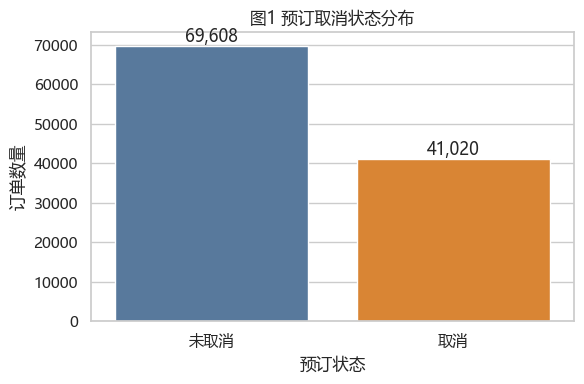

In [5]:
# 查看目标变量分布，判断取消和未取消样本是否明显不均衡。
target_counts = df["is_canceled"].value_counts().sort_index().rename(index={0: "未取消", 1: "取消"})
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, palette=["#4C78A8", "#F58518"])
ax.set_title("图1 预订取消状态分布")
ax.set_xlabel("预订状态")
ax.set_ylabel("订单数量")
for i, value in enumerate(target_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")
save_current_fig("fig01_target_distribution.png")

WindowsPath('reports/eda_figures/fig02_04_hotel_monthly_trends.png')

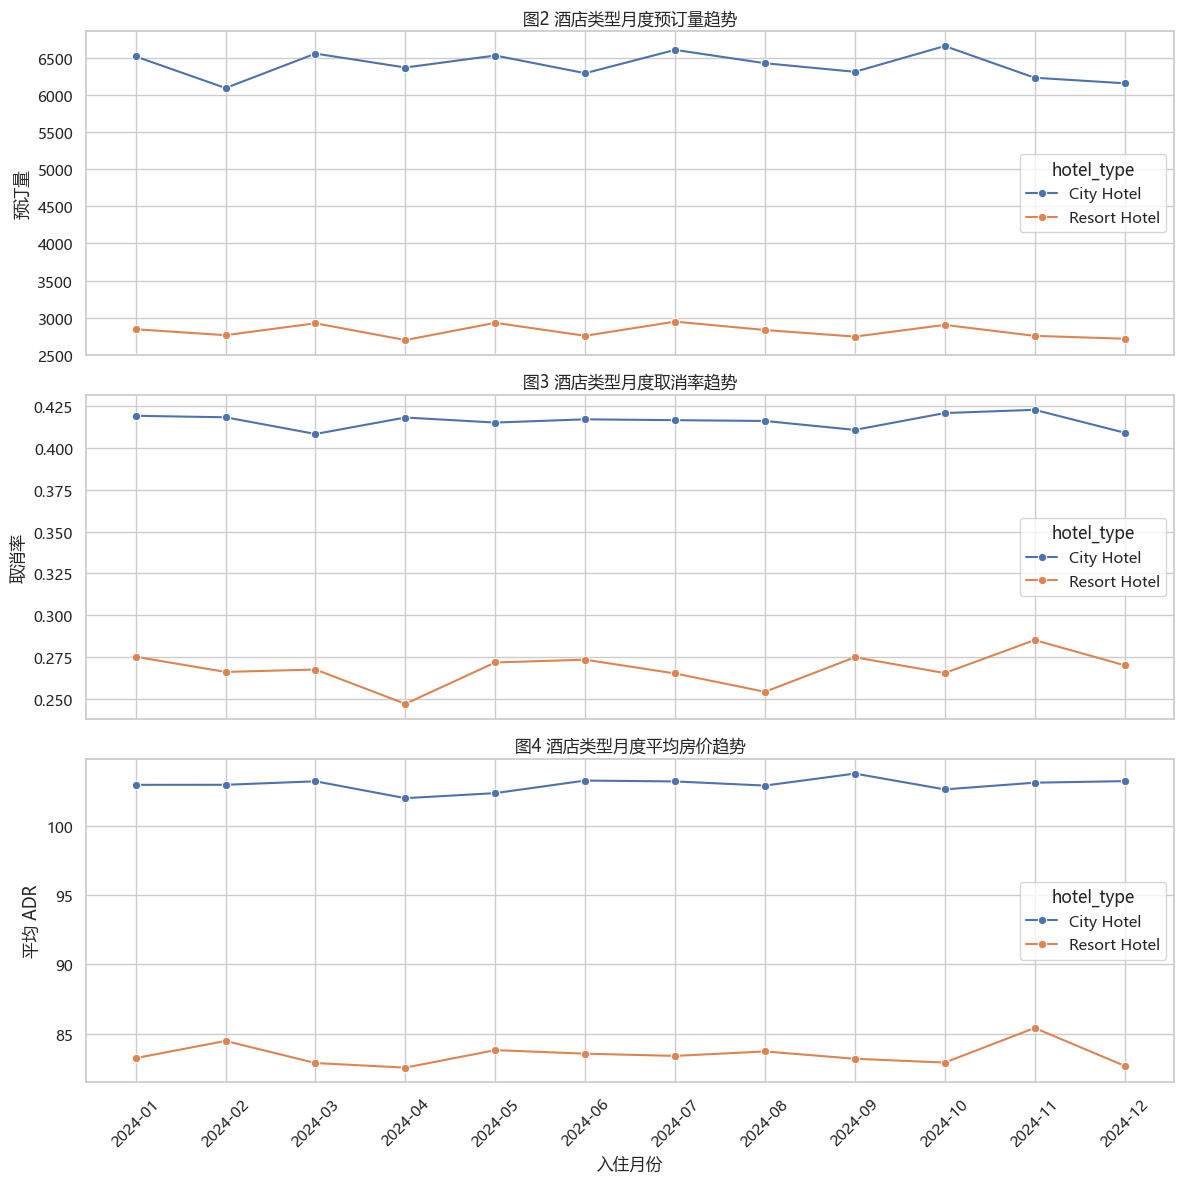

In [6]:
# 按月份和酒店类型观察预订量、取消率和平均房价趋势。
monthly = (
    df.groupby(["arrival_month", "hotel_type"])
    .agg(
        booking_count=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean"),
    )
    .reset_index()
)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
sns.lineplot(data=monthly, x="arrival_month", y="booking_count", hue="hotel_type", marker="o", ax=axes[0])
axes[0].set_title("图2 酒店类型月度预订量趋势")
axes[0].set_xlabel("")
axes[0].set_ylabel("预订量")
sns.lineplot(data=monthly, x="arrival_month", y="cancellation_rate", hue="hotel_type", marker="o", ax=axes[1])
axes[1].set_title("图3 酒店类型月度取消率趋势")
axes[1].set_xlabel("")
axes[1].set_ylabel("取消率")
sns.lineplot(data=monthly, x="arrival_month", y="avg_adr", hue="hotel_type", marker="o", ax=axes[2])
axes[2].set_title("图4 酒店类型月度平均房价趋势")
axes[2].set_xlabel("入住月份")
axes[2].set_ylabel("平均 ADR")
plt.xticks(rotation=45)
save_current_fig("fig02_04_hotel_monthly_trends.png")

## 5. 取消行为分析
本节重点分析取消率较高或差异较明显的订单特征。为避免只看比例造成误判，相关图表尽量同时展示预订量和取消率。

### 5.1 时间维度取消率
先观察月度预订量和取消率，用于判断取消行为是否存在明显时间波动。

WindowsPath('reports/eda_figures/fig05_monthly_booking_cancel_rate.png')

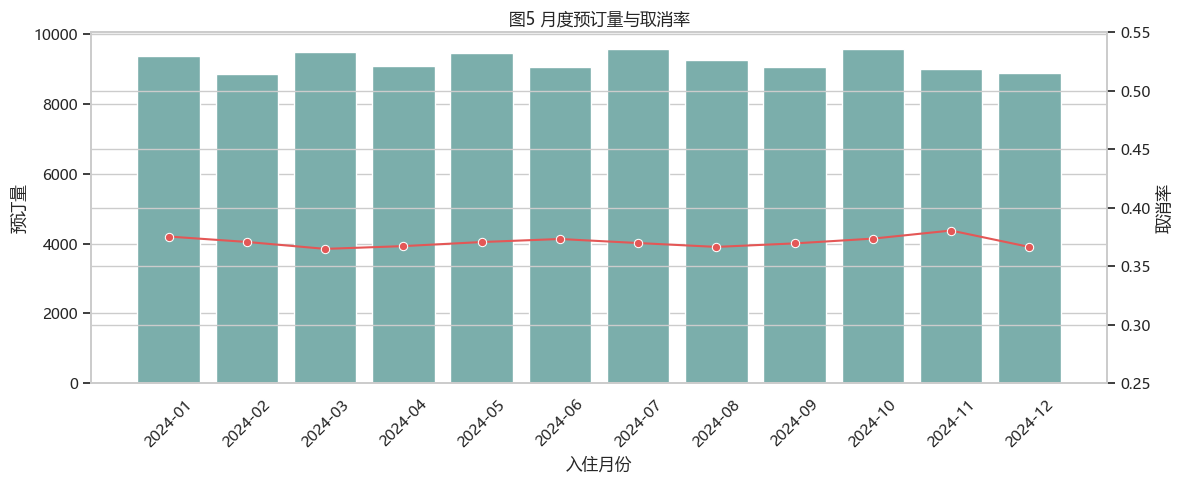

In [7]:
# 将月度预订量和取消率画在同一张图中，便于同时看规模和风险。
monthly_cancel = (
    df.groupby("arrival_month")
    .agg(booking_count=("is_canceled", "size"), cancellation_rate=("is_canceled", "mean"))
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(12, 5))
sns.barplot(data=monthly_cancel, x="arrival_month", y="booking_count", color="#72B7B2", ax=ax1)
ax1.set_ylabel("预订量")
ax1.set_xlabel("入住月份")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
sns.lineplot(data=monthly_cancel, x="arrival_month", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
# 扩大右轴范围，避免局部缩放导致取消率波动被视觉放大。
ax2.set_ylim(0.25, 0.55)
ax1.set_title("图5 月度预订量与取消率")
save_current_fig("fig05_monthly_booking_cancel_rate.png")


### 5.2 渠道、客户类型与市场细分
从分销渠道、客户类型和市场细分角度比较取消率差异，同时结合预订量判断样本规模。

,distribution_channel,booking_count,cancellation_count,cancellation_rate,avg_adr
3,TA/TO,90895,37370,0.411134,99.107254
1,Direct,13089,2203,0.168309,95.934685
0,Corporate,6450,1410,0.218605,69.050247
2,GDS,189,33,0.174603,120.083702
4,Undefined,5,4,0.800000,46.239998


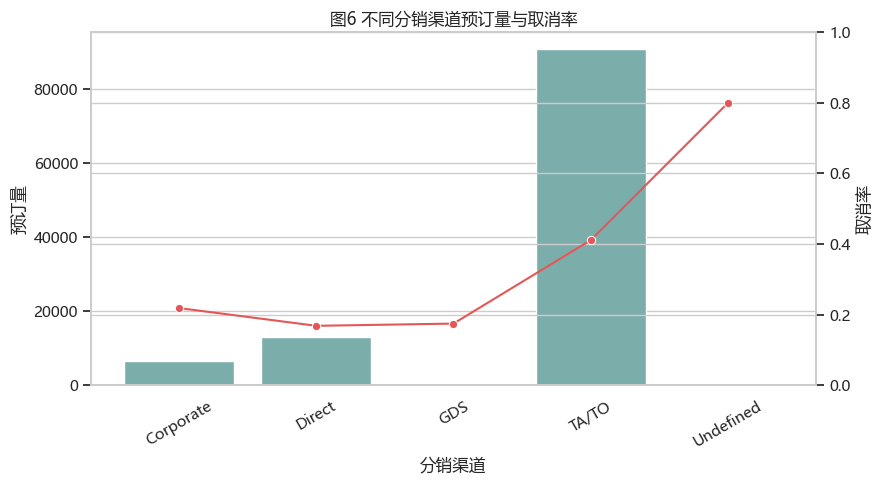

In [8]:
# 对分销渠道同时展示预订量和取消率，避免只看比例忽略样本量。
channel_cancel = rate_table(df, "distribution_channel")
fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(data=channel_cancel, x="distribution_channel", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("分销渠道")
ax1.set_ylabel("预订量")
ax1.tick_params(axis="x", rotation=30)
ax2 = ax1.twinx()
sns.lineplot(data=channel_cancel, x="distribution_channel", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图6 不同分销渠道预订量与取消率")
save_current_fig("fig06_channel_cancel_rate.png")
channel_cancel

,customer_type,booking_count,cancellation_count,cancellation_rate,avg_adr
2,Transient,82489,33575,0.407024,101.187119
3,Transient-Party,24272,6226,0.256510,84.434425
0,Contract,3325,1166,0.350677,88.253029
1,Group,542,53,0.097786,78.757309


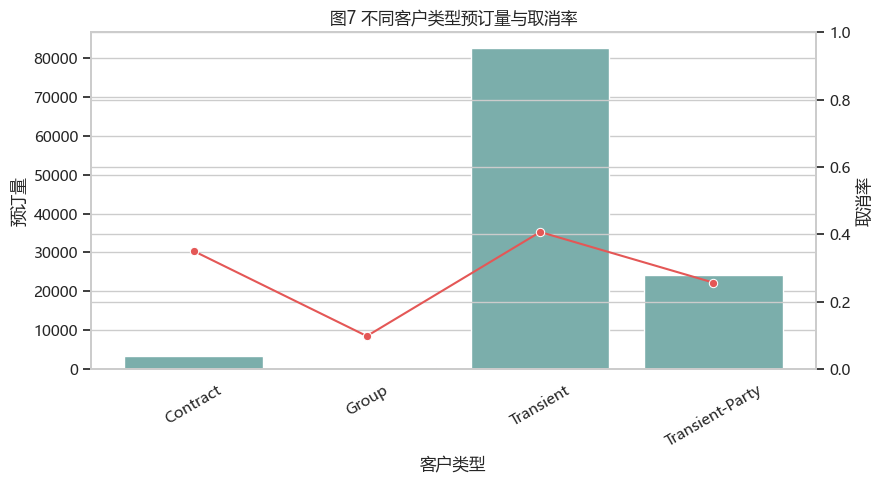

In [9]:
# 对客户类型同时展示预订量和取消率，比较不同客户群体的风险差异。
customer_cancel = rate_table(df, "customer_type")
fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(data=customer_cancel, x="customer_type", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("客户类型")
ax1.set_ylabel("预订量")
ax1.tick_params(axis="x", rotation=30)
ax2 = ax1.twinx()
sns.lineplot(data=customer_cancel, x="customer_type", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图7 不同客户类型预订量与取消率")
save_current_fig("fig07_customer_type_cancel_rate.png")
customer_cancel

### 5.3 预订行为相关因素
从提前预订天数、押金类型、是否回头客和特殊需求数量等订单行为角度观察取消风险。

,lead_time_group,booking_count,cancellation_count,cancellation_rate,avg_adr
2,31-90,27373,10310,0.376649,100.780060
3,91-180,23920,10855,0.453804,104.386528
4,181+,22730,13303,0.585262,90.511375
0,0-7,19039,1799,0.094490,86.021210
1,8-30,17566,4753,0.270580,101.428001


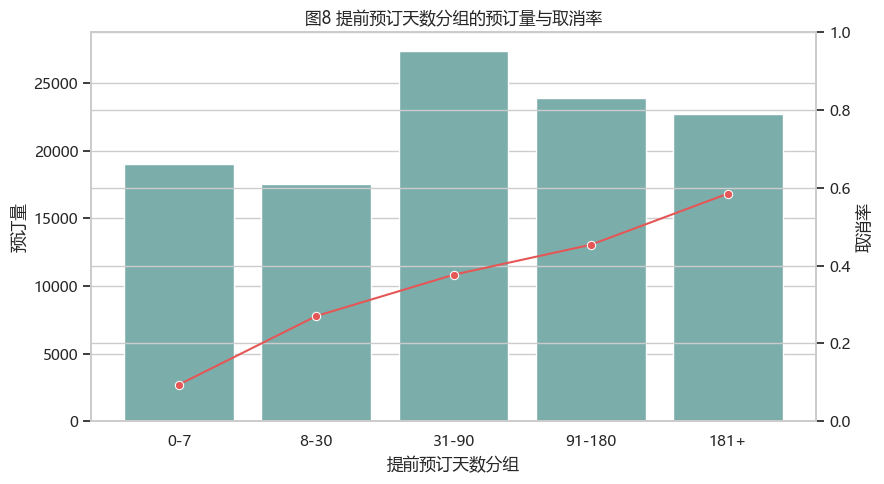

In [10]:
# 按提前预订天数分组观察取消率变化。
lead_time_cancel = rate_table(df, "lead_time_group")
fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(data=lead_time_cancel, x="lead_time_group", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("提前预订天数分组")
ax1.set_ylabel("预订量")
ax2 = ax1.twinx()
sns.lineplot(data=lead_time_cancel, x="lead_time_group", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图8 提前预订天数分组的预订量与取消率")
save_current_fig("fig08_lead_time_cancel_rate.png")
lead_time_cancel

,deposit_type,booking_count,cancellation_count,cancellation_rate,avg_adr
0,No Deposit,95995,26604,0.277139,98.207138
1,Non Refund,14479,14388,0.993715,89.358849
2,Refundable,154,28,0.181818,72.226555


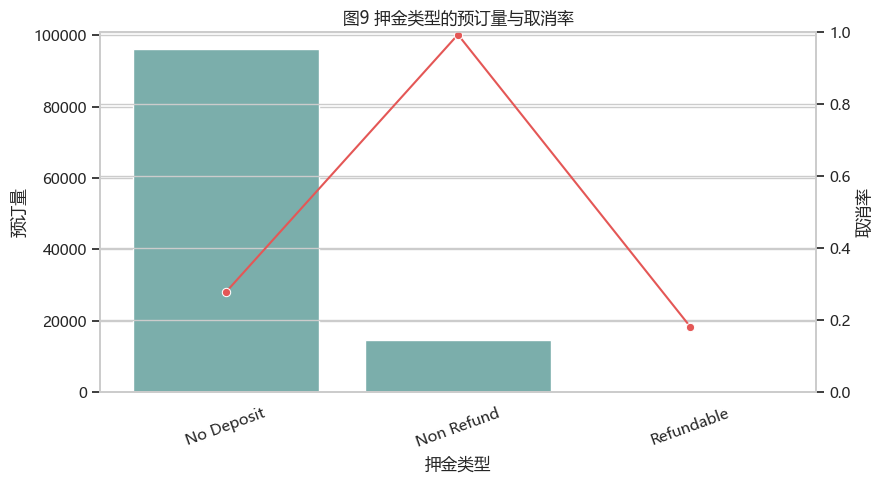

In [11]:
# 按押金类型观察取消率，重点关注样本量和极端比例。
deposit_cancel = rate_table(df, "deposit_type")
fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(data=deposit_cancel, x="deposit_type", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("押金类型")
ax1.set_ylabel("预订量")
ax1.tick_params(axis="x", rotation=20)
ax2 = ax1.twinx()
sns.lineplot(data=deposit_cancel, x="deposit_type", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图9 押金类型的预订量与取消率")
save_current_fig("fig09_deposit_type_cancel_rate.png")
deposit_cancel

,market_segment,booking_count,cancellation_count,cancellation_rate,avg_adr
6,Online TA,51533,18323,0.355559,110.879013
5,Offline TA/TO,22461,8079,0.359690,86.648308
4,Groups,19417,11917,0.613741,78.798798
3,Direct,11144,1609,0.144383,104.423737
2,Corporate,5123,946,0.184657,69.320679
1,Complementary,736,97,0.131793,2.913818
0,Aviation,212,47,0.221698,99.856979
7,Undefined,2,2,1.000000,15.000000


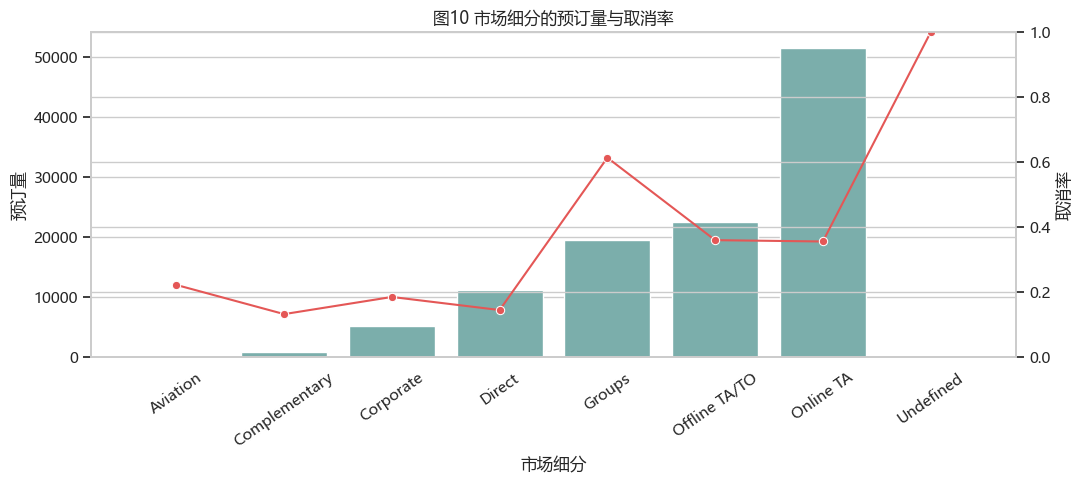

In [12]:
# 按市场细分观察预订规模和取消率差异。
market_cancel = rate_table(df, "market_segment")
fig, ax1 = plt.subplots(figsize=(11, 5))
sns.barplot(data=market_cancel, x="market_segment", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("市场细分")
ax1.set_ylabel("预订量")
ax1.tick_params(axis="x", rotation=35)
ax2 = ax1.twinx()
sns.lineplot(data=market_cancel, x="market_segment", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图10 市场细分的预订量与取消率")
save_current_fig("fig10_market_segment_cancel_rate.png")
market_cancel

,is_repeated_guest,booking_count,cancellation_count,cancellation_rate,avg_adr,guest_type
0,0,106950,40483,0.378523,98.253876,新客户
1,1,3678,537,0.146003,60.927639,回头客


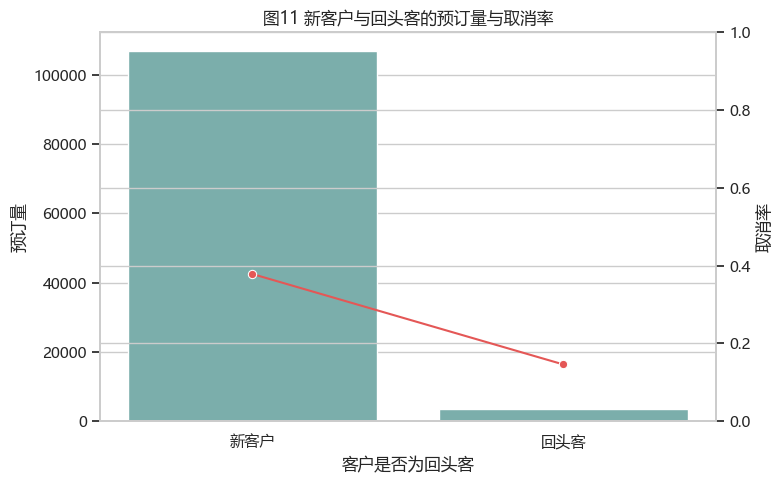

In [13]:
# 对比新客户和回头客的预订量与取消率。
repeated_guest_cancel = rate_table(df, "is_repeated_guest")
repeated_guest_cancel["guest_type"] = repeated_guest_cancel["is_repeated_guest"].map({0: "新客户", 1: "回头客"})
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data=repeated_guest_cancel, x="guest_type", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("客户是否为回头客")
ax1.set_ylabel("预订量")
ax2 = ax1.twinx()
sns.lineplot(data=repeated_guest_cancel, x="guest_type", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图11 新客户与回头客的预订量与取消率")
save_current_fig("fig11_repeated_guest_cancel_rate.png")
repeated_guest_cancel

,special_request_group,booking_count,cancellation_count,cancellation_rate,avg_adr
0,0,66097,31630,0.478539,91.173119
1,1,30359,6422,0.211535,103.168839
2,2,11678,2531,0.216732,110.390450
3,3,2189,403,0.184102,114.449692
4,4,272,32,0.117647,112.326324
5,5+,33,2,0.060606,113.606667


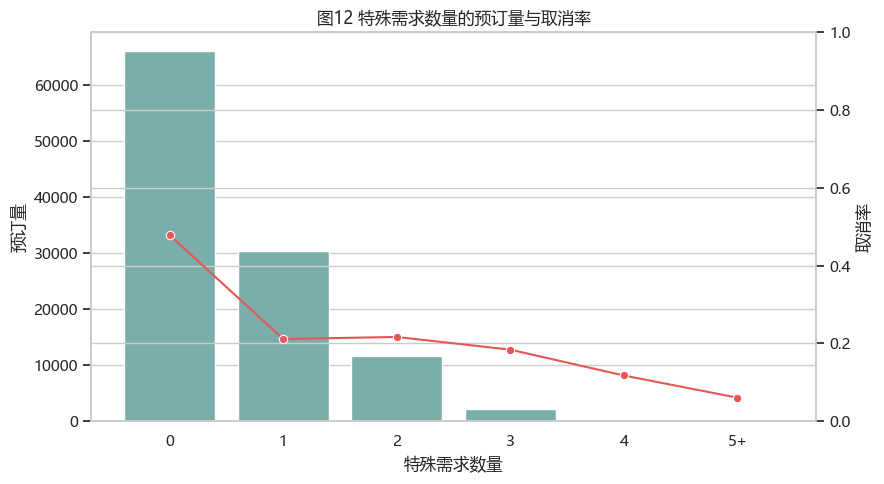

In [14]:
# 按特殊需求数量观察取消率，特殊需求可能反映订单确定性。
request_cancel = rate_table(df, "special_request_group")
request_order = ["0", "1", "2", "3", "4", "5+"]
request_cancel["special_request_group"] = pd.Categorical(
    request_cancel["special_request_group"], categories=request_order, ordered=True
)
request_cancel = request_cancel.sort_values("special_request_group")
fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(data=request_cancel, x="special_request_group", y="booking_count", ax=ax1, color="#72B7B2")
ax1.set_xlabel("特殊需求数量")
ax1.set_ylabel("预订量")
ax2 = ax1.twinx()
sns.lineplot(data=request_cancel, x="special_request_group", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax2.set_ylim(0, 1)
ax1.set_title("图12 特殊需求数量的预订量与取消率")
save_current_fig("fig12_special_requests_cancel_rate.png")
request_cancel

## 6. 用户分群分析：RFM 客户群体

In [15]:
# 汇总 RFM 客户群体的订单量、取消率和估算消费金额。
rfm_summary = (
    df.groupby("rfm_segment")
    .agg(
        booking_count=("is_canceled", "size"),
        avg_cancellation_rate=("is_canceled", "mean"),
        avg_revenue=("estimated_revenue", "mean"),
    )
    .reset_index()
)
rfm_summary

,rfm_segment,booking_count,avg_cancellation_rate,avg_revenue
0,沉睡,335,0.119403,80.168327
1,流失,32,0.156250,56.929375
2,潜力,1254,0.121212,73.300720
3,高价值,109007,0.374499,305.709381


WindowsPath('reports/eda_figures/fig09_10_rfm_segments.png')

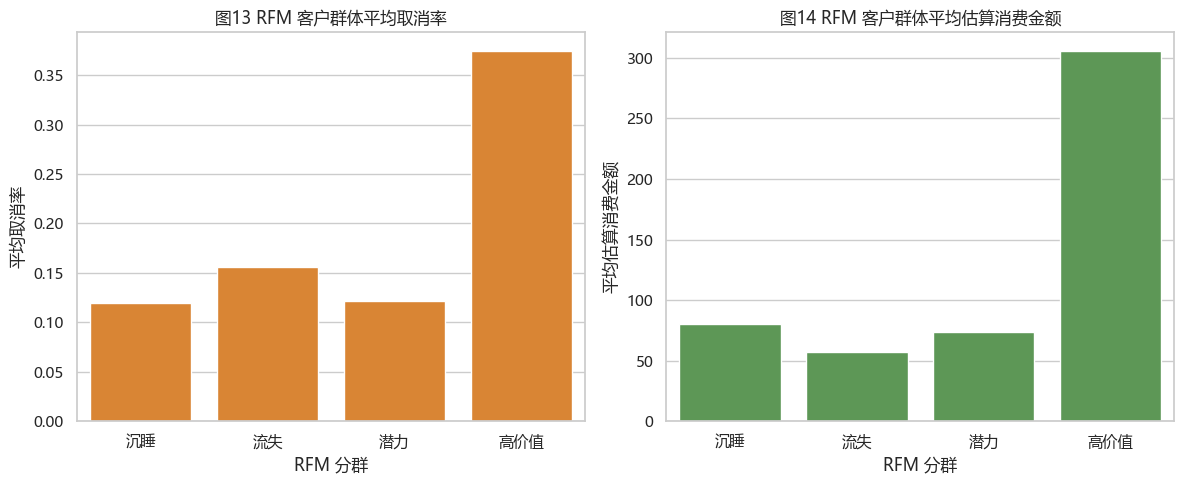

In [16]:
# 将 RFM 分群的取消率和估算消费金额并排展示。
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=rfm_summary, x="rfm_segment", y="avg_cancellation_rate", ax=axes[0], color="#F58518")
axes[0].set_title("图13 RFM 客户群体平均取消率")
axes[0].set_xlabel("RFM 分群")
axes[0].set_ylabel("平均取消率")
sns.barplot(data=rfm_summary, x="rfm_segment", y="avg_revenue", ax=axes[1], color="#54A24B")
axes[1].set_title("图14 RFM 客户群体平均估算消费金额")
axes[1].set_xlabel("RFM 分群")
axes[1].set_ylabel("平均估算消费金额")
save_current_fig("fig13_14_rfm_segments.png")


## 7. 价格分析

C:\Users\Ted\AppData\Local\Temp\ipykernel_19512\4074240445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_canceled", y="adr", ax=ax, palette=["#4C78A8", "#F58518"])


WindowsPath('reports/eda_figures/fig11_adr_by_cancel_status.png')

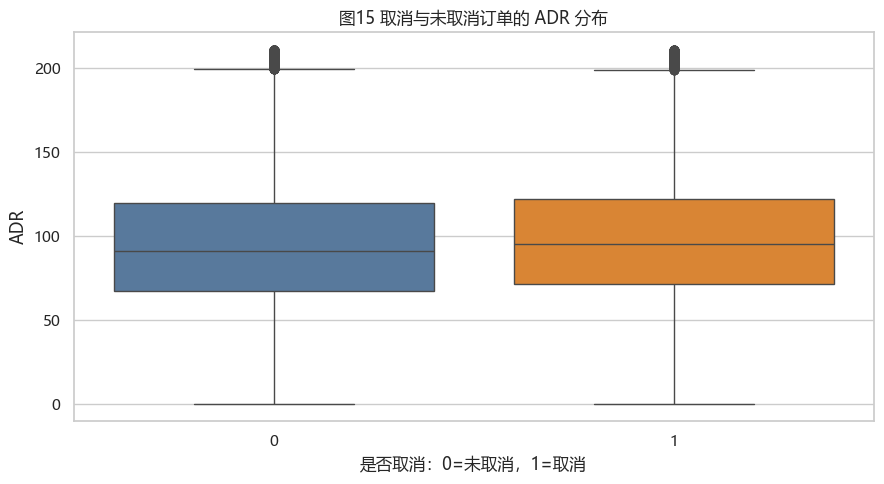

In [17]:
# 用箱线图比较取消和未取消订单的 ADR 分布。
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="is_canceled", y="adr", ax=ax, palette=["#4C78A8", "#F58518"])
ax.set_title("图15 取消与未取消订单的 ADR 分布")
ax.set_xlabel("是否取消：0=未取消，1=取消")
ax.set_ylabel("ADR")
save_current_fig("fig15_adr_by_cancel_status.png")

,adr_bin,booking_count,cancellation_rate,avg_adr
0,"(-0.001, 63.4]",22142,0.354711,45.541222
1,"(63.4, 84.0]",22178,0.340427,73.629669
2,"(84.0, 102.33]",22060,0.393790,92.923599
3,"(102.33, 130.0]",23079,0.392218,115.915085
4,"(130.0, 211.03]",21169,0.372101,159.001953


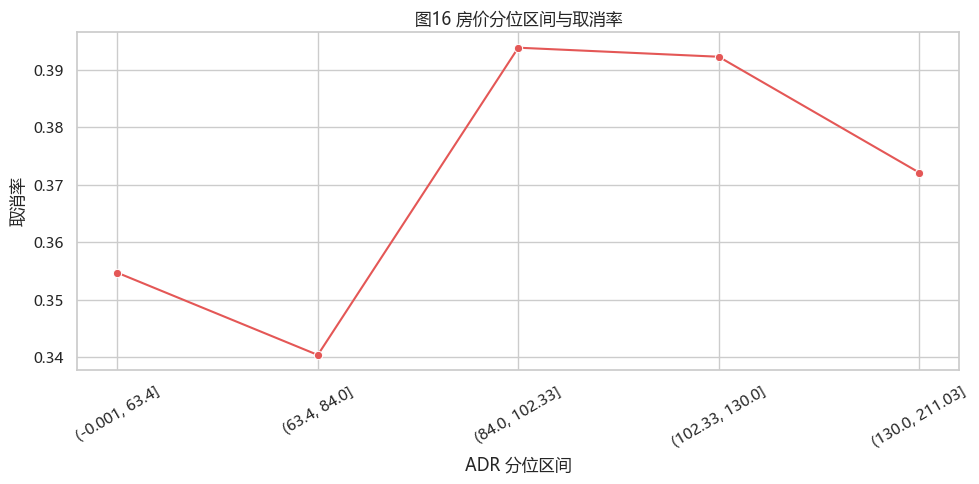

In [18]:
# 将 ADR 按分位数分箱，观察不同价格区间的取消率。
df["adr_bin"] = pd.qcut(df["adr"], q=5, duplicates="drop")
adr_cancel = (
    df.groupby("adr_bin", observed=True)
    .agg(booking_count=("is_canceled", "size"), cancellation_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"))
    .reset_index()
)
adr_cancel["adr_bin"] = adr_cancel["adr_bin"].astype(str)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=adr_cancel, x="adr_bin", y="cancellation_rate", marker="o", ax=ax, color="#E45756")
ax.set_title("图16 房价分位区间与取消率")
ax.set_xlabel("ADR 分位区间")
ax.set_ylabel("取消率")
plt.xticks(rotation=30)
save_current_fig("fig16_adr_bin_cancel_rate.png")
adr_cancel

,reserved_room_type,booking_count,cancellation_rate,avg_adr
0,A,82916,0.391674,89.822632
3,D,17176,0.317012,117.456436
4,E,5151,0.281499,113.046783
5,F,2071,0.275712,144.144363
6,G,1234,0.328201,128.738098
1,B,1077,0.324048,88.536934
2,C,620,0.296774,128.258194
7,H,366,0.346995,141.711502
9,P,11,1.000000,0.000000
8,L,6,0.333333,124.666664


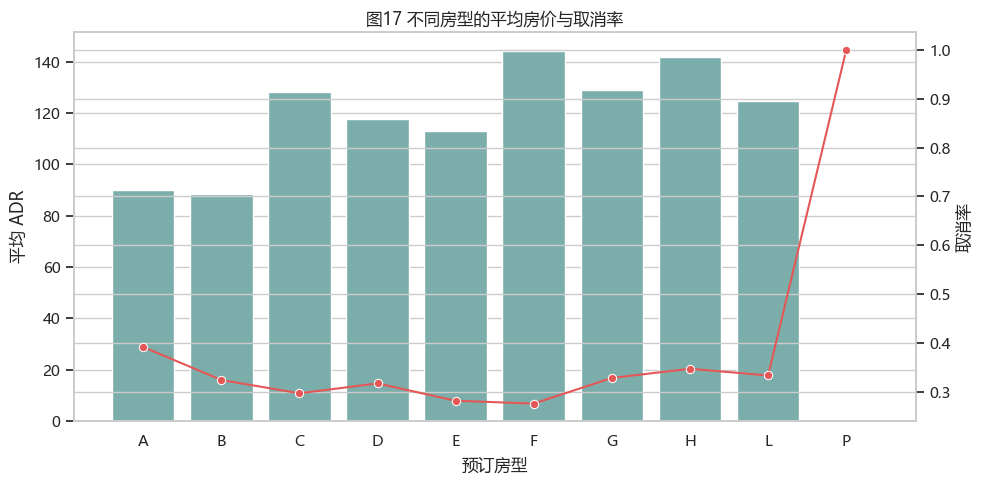

In [19]:
# 按预订房型比较平均房价和取消率。
room_price = (
    df.groupby("reserved_room_type")
    .agg(
        booking_count=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean"),
    )
    .reset_index()
    .sort_values("booking_count", ascending=False)
)
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=room_price, x="reserved_room_type", y="avg_adr", color="#72B7B2", ax=ax1)
ax1.set_ylabel("平均 ADR")
ax1.set_xlabel("预订房型")
ax2 = ax1.twinx()
sns.lineplot(data=room_price, x="reserved_room_type", y="cancellation_rate", marker="o", color="#E45756", ax=ax2)
ax2.set_ylabel("取消率")
ax1.set_title("图17 不同房型的平均房价与取消率")
save_current_fig("fig17_room_price_cancel_rate.png")
room_price

## 8. 渠道分析

,distribution_channel,booking_count,cancellation_rate,avg_adr
3,TA/TO,90895,0.411134,99.107254
1,Direct,13089,0.168309,95.934685
0,Corporate,6450,0.218605,69.050247
2,GDS,189,0.174603,120.083702
4,Undefined,5,0.800000,46.239998


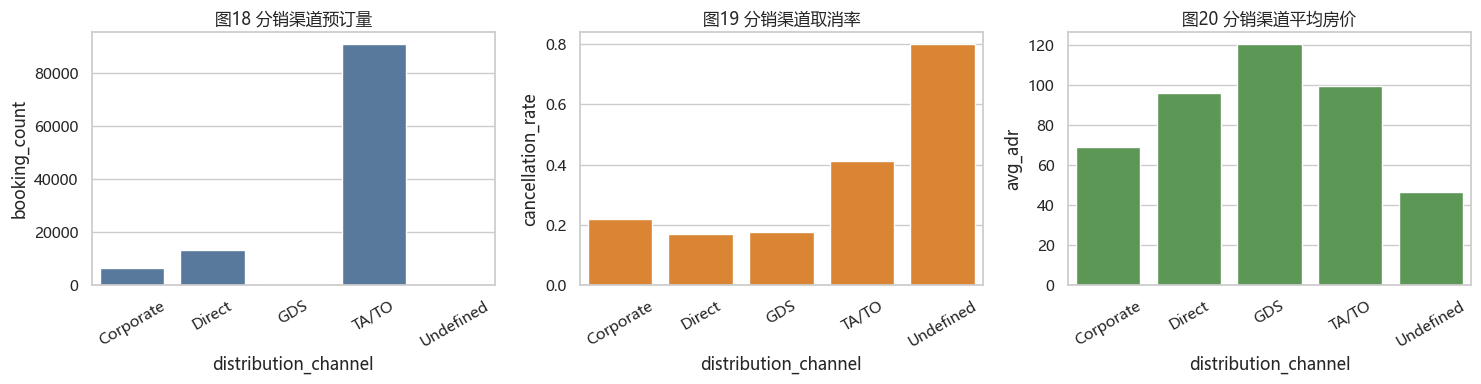

In [20]:
# 对渠道维度分别比较预订量、取消率和平均房价。
channel_analysis = (
    df.groupby("distribution_channel")
    .agg(
        booking_count=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean"),
    )
    .reset_index()
    .sort_values("booking_count", ascending=False)
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=channel_analysis, x="distribution_channel", y="booking_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("图18 分销渠道预订量")
sns.barplot(data=channel_analysis, x="distribution_channel", y="cancellation_rate", ax=axes[1], color="#F58518")
axes[1].set_title("图19 分销渠道取消率")
sns.barplot(data=channel_analysis, x="distribution_channel", y="avg_adr", ax=axes[2], color="#54A24B")
axes[2].set_title("图20 分销渠道平均房价")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
save_current_fig("fig18_20_channel_analysis.png")
channel_analysis

## 9. 季节性分析

,season_type,booking_count,cancellation_rate,avg_adr
0,旺季,28613,0.369517,96.899963
1,淡季,26729,0.372704,97.280373


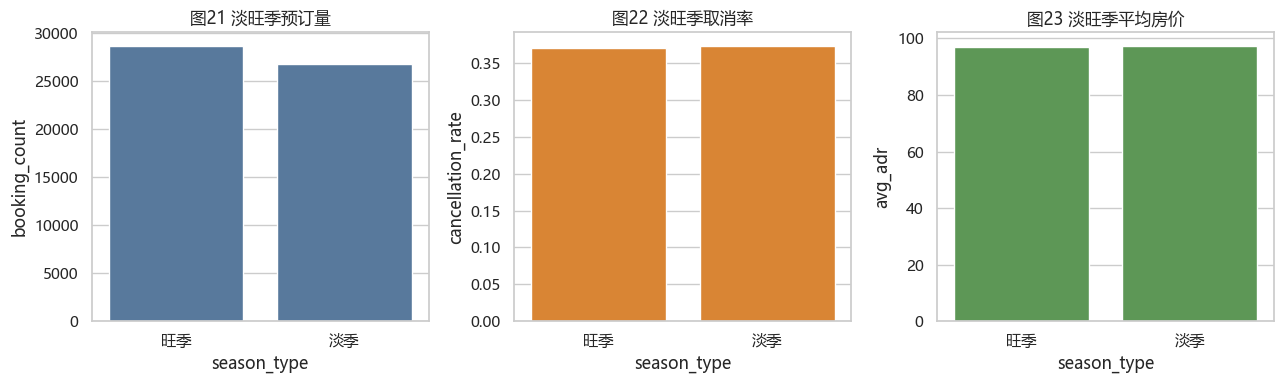

In [21]:
# 对淡季和旺季进行对比，检查季节性特征是否有明显区分度。
season_summary = (
    df[df["season_type"].isin(["淡季", "旺季"])]
    .groupby("season_type")
    .agg(booking_count=("is_canceled", "size"), cancellation_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"))
    .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.barplot(data=season_summary, x="season_type", y="booking_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("图21 淡旺季预订量")
sns.barplot(data=season_summary, x="season_type", y="cancellation_rate", ax=axes[1], color="#F58518")
axes[1].set_title("图22 淡旺季取消率")
sns.barplot(data=season_summary, x="season_type", y="avg_adr", ax=axes[2], color="#54A24B")
axes[2].set_title("图23 淡旺季平均房价")
save_current_fig("fig21_23_season_analysis.png")
season_summary

### 9.1 周末节假日代理分析
本项目当前不引入外部法定节假日日历。根据本阶段分析口径，将周六和周日作为节假日/休闲出行日的近似代理变量，用于比较周末与工作日的预订量、取消率和平均房价差异。

,holiday_proxy,booking_count,cancellation_rate,avg_adr
0,周末/节假日代理,31719,0.373593,96.894180
1,工作日,78909,0.369666,97.060631


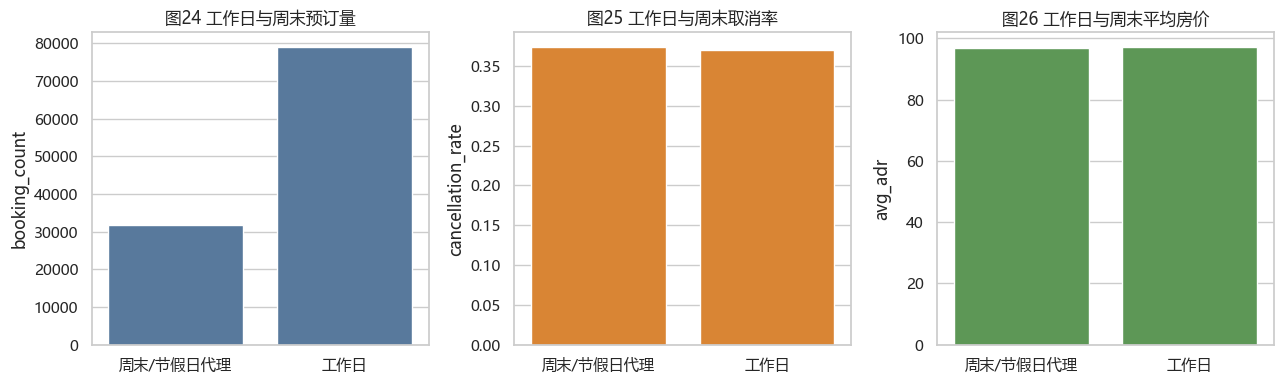

In [22]:
# 使用周末作为节假日代理，对比工作日和周末订单表现。
holiday_proxy_summary = (
    df.groupby("holiday_proxy")
    .agg(
        booking_count=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean"),
    )
    .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.barplot(data=holiday_proxy_summary, x="holiday_proxy", y="booking_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("图24 工作日与周末预订量")
sns.barplot(data=holiday_proxy_summary, x="holiday_proxy", y="cancellation_rate", ax=axes[1], color="#F58518")
axes[1].set_title("图25 工作日与周末取消率")
sns.barplot(data=holiday_proxy_summary, x="holiday_proxy", y="avg_adr", ax=axes[2], color="#54A24B")
axes[2].set_title("图26 工作日与周末平均房价")
for ax in axes:
    ax.set_xlabel("")
save_current_fig("fig24_26_weekend_holiday_proxy_analysis.png")
holiday_proxy_summary

## 10. EDA 阶段性结论

In [23]:
# 汇总 EDA 观察结论，供实验报告和后续建模参考。
insights = [
    f"整体取消率为 {df['is_canceled'].mean():.2%}，取消订单占比较高，后续模型评估不能只看准确率。",
    "月度取消率整体波动较小，月份本身对取消行为的区分度有限，但可作为候选时间特征保留。",
    "分销渠道、客户类型、市场细分、押金类型、提前预订天数和特殊需求数量之间存在取消率差异，且需要结合预订量判断样本规模。",
    "提前预订时间越长，取消率整体更高，是后续特征工程和建模中值得重点关注的变量。",
    "RFM 分群显示不同客户群体的取消率和平均估算消费金额存在差异，但该分析基于客户属性组合。",
    "基于月度预订量划分的淡旺季在取消率和平均房价上差异较小，说明该季节性口径对取消行为的解释力有限。",
]
for item in insights:
    print("- " + item)


- 整体取消率为 37.08%，取消订单占比较高，后续模型评估不能只看准确率。
- 月度取消率整体波动较小，月份本身对取消行为的区分度有限，但可作为候选时间特征保留。
- 分销渠道、客户类型、市场细分、押金类型、提前预订天数和特殊需求数量之间存在取消率差异，且需要结合预订量判断样本规模。
- 提前预订时间越长，取消率整体更高，是后续特征工程和建模中值得重点关注的变量。
- RFM 分群显示不同客户群体的取消率和平均估算消费金额存在差异，但该分析基于客户属性组合。
- 基于月度预订量划分的淡旺季在取消率和平均房价上差异较小，说明该季节性口径对取消行为的解释力有限。
